# Modelagem, Feature Engineering e Avaliacao

De forma macro, ele cobre quatro frentes:

1. leitura do dataset confiavel e contextualizacao do problema;
2. engenharia e validacao das features derivadas;
3. benchmark completo dos modelos e geracao de artefatos;
4. interpretacao tecnica e executiva dos resultados.

In [ ]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from IPython.display import Image, Markdown, display

from pathlib import Path

sns.set_theme(style="whitegrid", palette="viridis")

In [50]:
matplotlib.use("Agg")
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
)

RANDOM_STATE = 42
TEST_SIZE = 0.20

try:
    base_dir = Path(__file__).resolve().parent
except NameError:
    base_dir = Path.cwd()

ROOT_DIR = base_dir.parent
DATASET_PATH = ROOT_DIR / "data" / "trusted" / "train.parquet"
ENGINEERED_DATASET_PATH = ROOT_DIR / "data" / "refined" / "train_engineered.parquet"
ARTIFACTS_DIR = ROOT_DIR / "artifacts" / "modeling"

FEATURE_NOTES = {
    "avg_seconds_per_call": "Regra de negocio: mede a intensidade media de cada ligacao. Ajuda a separar clientes que usam pouco a rede daqueles que fazem menos chamadas, mas chamadas mais longas.",
    "sms_per_call": "Regra de negocio: compara o uso de SMS com o volume de chamadas. Ajuda a identificar perfis mais orientados a mensagem do que a voz tradicional.",
    "calls_per_contact": "Regra de negocio: mede o quanto o cliente concentra chamadas em poucos numeros. Valores altos indicam rede de contato mais concentrada.",
    "contact_diversity_ratio": "Regra de negocio: mede a diversidade de contatos em relacao ao volume de chamadas. Ajuda a diferenciar clientes com rede social mais ampla.",
    "call_failure_rate": "Regra de negocio: resume a friccao operacional das chamadas. Se a taxa de falha sobe, existe sinal de experiencia ruim e maior propensao a churn.",
    "usage_per_month": "Regra de negocio: normaliza o tempo de uso pela antiguidade do cliente. Evita superestimar clientes antigos apenas por acumularem mais consumo.",
    "calls_per_month": "Regra de negocio: normaliza a frequencia de chamadas pelo tempo de base. Ajuda a capturar intensidade recorrente de uso.",
    "sms_per_month": "Regra de negocio: normaliza o uso de SMS pela antiguidade. Permite comparar perfis com tempos de relacionamento diferentes.",
    "value_per_month": "Regra de negocio: aproxima a monetizacao media mensal do cliente. Ajuda a entender valor economico recorrente.",
    "value_per_call": "Regra de negocio: relaciona valor gerado com o volume de chamadas. Ajuda a separar clientes que geram mais valor mesmo sem alto volume.",
    "complaint_status_interaction": "Regra de negocio: combina reclamacao com status operacional. O objetivo e capturar quando insatisfacao e contexto operacional ruim aparecem juntos.",
    "charge_value_gap": "Regra de negocio: mede a diferenca entre cobranca nominal e valor percebido ou capturado. Pode sinalizar desalinhamento economico.",
    "tenure_age_ratio": "Regra de negocio: relaciona tempo de base com idade do cliente. Funciona como proxy de ciclo de vida e maturidade de relacionamento.",
    "usage_value_efficiency": "Regra de negocio: compara o quanto de uso e entregue por unidade de valor. Pode sinalizar percepcao de custo-beneficio.",
}


In [51]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    eps = 1.0

    # Ratios expose behavior more clearly than raw totals for churn.
    data["avg_seconds_per_call"] = data["seconds_of_use"] / (data["frequency_of_use"] + eps)
    data["sms_per_call"] = data["frequency_of_sms"] / (data["frequency_of_use"] + eps)
    data["calls_per_contact"] = data["frequency_of_use"] / (
        data["distinct_called_numbers"] + eps
    )
    data["contact_diversity_ratio"] = data["distinct_called_numbers"] / (
        data["frequency_of_use"] + eps
    )
    data["call_failure_rate"] = data["call_failure"] / (
        data["frequency_of_use"] + data["call_failure"] + eps
    )
    data["usage_per_month"] = data["seconds_of_use"] / (data["subscription_length"] + eps)
    data["calls_per_month"] = data["frequency_of_use"] / (data["subscription_length"] + eps)
    data["sms_per_month"] = data["frequency_of_sms"] / (data["subscription_length"] + eps)
    data["value_per_month"] = data["customer_value"] / (data["subscription_length"] + eps)
    data["value_per_call"] = data["customer_value"] / (data["frequency_of_use"] + eps)
    data["complaint_status_interaction"] = data["complains"] * data["status"]
    data["charge_value_gap"] = data["customer_value"] - data["charge_amount"]
    data["tenure_age_ratio"] = data["subscription_length"] / (data["age"] + eps)
    data["usage_value_efficiency"] = data["seconds_of_use"] / (data["customer_value"] + eps)

    return data


def build_preprocessors(feature_names: list[str]) -> tuple[ColumnTransformer, ColumnTransformer]:
    # Linear models benefit from scaling; tree models do not need it.
    scaled = ColumnTransformer(
        [
            (
                "num",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                feature_names,
            )
        ]
    )
    tree = ColumnTransformer(
        [
            (
                "num",
                Pipeline([("imputer", SimpleImputer(strategy="median"))]),
                feature_names,
            )
        ]
    )
    return scaled, tree


def build_models(feature_names: list[str], scale_pos_weight: float) -> dict[str, Pipeline]:
    scaled_preprocessor, tree_preprocessor = build_preprocessors(feature_names)

    # Use a mixed benchmark: linear, bagging, boosting, and gradient tree libraries.
    return {
        "Logistic Regression": Pipeline(
            [
                ("prep", scaled_preprocessor),
                (
                    "model",
                    LogisticRegression(
                        max_iter=2_000,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "Random Forest": Pipeline(
            [
                ("prep", tree_preprocessor),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=400,
                        min_samples_leaf=2,
                        class_weight="balanced_subsample",
                        n_jobs=1,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "Extra Trees": Pipeline(
            [
                ("prep", tree_preprocessor),
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=500,
                        min_samples_leaf=2,
                        class_weight="balanced",
                        n_jobs=1,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "Gradient Boosting": Pipeline(
            [
                ("prep", tree_preprocessor),
                (
                    "model",
                    GradientBoostingClassifier(
                        n_estimators=250,
                        learning_rate=0.05,
                        max_depth=3,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "XGBoost": Pipeline(
            [
                ("prep", tree_preprocessor),
                (
                    "model",
                    XGBClassifier(
                        n_estimators=350,
                        max_depth=4,
                        learning_rate=0.05,
                        subsample=0.9,
                        colsample_bytree=0.8,
                        reg_lambda=1.0,
                        scale_pos_weight=scale_pos_weight,
                        eval_metric="logloss",
                        n_jobs=1,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "LightGBM": Pipeline(
            [
                ("prep", tree_preprocessor),
                (
                    "model",
                    LGBMClassifier(
                        n_estimators=350,
                        learning_rate=0.05,
                        num_leaves=31,
                        subsample=0.9,
                        colsample_bytree=0.8,
                        class_weight="balanced",
                        n_jobs=1,
                        random_state=RANDOM_STATE,
                        verbosity=-1,
                    ),
                ),
            ]
        ),
    }


def evaluate_with_cross_validation(
    X: pd.DataFrame,
    y: pd.Series,
    models: dict[str, Pipeline],
) -> pd.DataFrame:
    # Stratification preserves the churn rate across folds.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {
        "roc_auc": "roc_auc",
        "average_precision": "average_precision",
        "recall": "recall",
        "precision": "precision",
        "f1": "f1",
        "balanced_accuracy": "balanced_accuracy",
    }

    rows: list[dict[str, float | str]] = []

    for name, pipeline in models.items():
        # Keep evaluation homogeneous so model ranking is comparable.
        scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=1)
        row: dict[str, float | str] = {"model": name}
        for metric in scoring:
            row[f"cv_{metric}_mean"] = float(scores[f"test_{metric}"].mean())
            row[f"cv_{metric}_std"] = float(scores[f"test_{metric}"].std())
        rows.append(row)

    return pd.DataFrame(rows).sort_values("cv_roc_auc_mean", ascending=False).reset_index(
        drop=True
    )


def evaluate_on_holdout(
    X: pd.DataFrame,
    y: pd.Series,
    models: dict[str, Pipeline],
) -> tuple[pd.DataFrame, dict[str, np.ndarray], pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    # A final holdout simulates model behavior on unseen data after benchmark selection.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    holdout_rows: list[dict[str, float | str]] = []
    probabilities: dict[str, np.ndarray] = {}

    for name, pipeline in models.items():
        pipeline.fit(X_train, y_train)
        # Keep probabilities for thresholding, ROC/PR, and comparison plots.
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= 0.50).astype(int)
        probabilities[name] = y_proba
        holdout_rows.append(
            {
                "model": name,
                "test_accuracy": float(accuracy_score(y_test, y_pred)),
                "test_balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
                "test_precision": float(precision_score(y_test, y_pred)),
                "test_recall": float(recall_score(y_test, y_pred)),
                "test_f1": float(f1_score(y_test, y_pred)),
                "test_roc_auc": float(roc_auc_score(y_test, y_proba)),
                "test_average_precision": float(average_precision_score(y_test, y_proba)),
            }
        )

    return (
        pd.DataFrame(holdout_rows).sort_values("test_roc_auc", ascending=False).reset_index(
            drop=True
        ),
        probabilities,
        X_train,
        y_train,
        X_test,
        y_test,
    )


def compare_raw_vs_engineered(raw_df: pd.DataFrame, engineered_df: pd.DataFrame) -> pd.DataFrame:
    results: list[dict[str, float | str]] = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {
        "roc_auc": "roc_auc",
        "average_precision": "average_precision",
        "f1": "f1",
    }

    for label, dataset in (("raw_features", raw_df), ("engineered_features", engineered_df)):
        # Fix the model family to isolate the effect of feature engineering.
        X = dataset.drop(columns=["churn"])
        y = dataset["churn"].astype(int)
        scale_pos_weight = (y == 0).sum() / (y == 1).sum()
        model = build_models(X.columns.tolist(), scale_pos_weight)["XGBoost"]
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=1)
        results.append(
            {
                "feature_set": label,
                "roc_auc": float(scores["test_roc_auc"].mean()),
                "average_precision": float(scores["test_average_precision"].mean()),
                "f1": float(scores["test_f1"].mean()),
            }
        )

    return pd.DataFrame(results)


def build_threshold_table(
    y_true: pd.Series,
    y_proba: np.ndarray,
) -> tuple[pd.DataFrame, float]:
    # Threshold analysis is useful when recall and precision have different business costs.
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    valid_precision = precision[:-1]
    valid_recall = recall[:-1]
    valid_thresholds = thresholds
    f1 = 2 * (valid_precision * valid_recall) / np.clip(valid_precision + valid_recall, 1e-9, None)

    threshold_df = pd.DataFrame(
        {
            "threshold": valid_thresholds,
            "precision": valid_precision,
            "recall": valid_recall,
            "f1": f1,
        }
    )
    best_threshold = float(threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"])
    return threshold_df, best_threshold


def plot_model_comparison(holdout_df: pd.DataFrame, output_path: Path) -> None:
    metric_columns = [
        "test_roc_auc",
        "test_average_precision",
        "test_f1",
        "test_recall",
        "test_precision",
        "test_balanced_accuracy",
    ]
    plot_df = holdout_df.melt(
        id_vars="model",
        value_vars=metric_columns,
        var_name="metric",
        value_name="score",
    )

    plt.figure(figsize=(13, 6))
    sns.barplot(data=plot_df, x="model", y="score", hue="metric", palette="viridis")
    plt.ylim(0.45, 1.02)
    plt.xlabel("")
    plt.ylabel("Score")
    plt.title("Comparacao de metricas no holdout")
    plt.xticks(rotation=20, ha="right")
    plt.legend(title="Metrica", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.close()


def plot_roc_and_pr_curves(
    y_test: pd.Series,
    probabilities: dict[str, np.ndarray],
    roc_output_path: Path,
    pr_output_path: Path,
) -> None:
    plt.figure(figsize=(8, 6))
    for name, y_proba in probabilities.items():
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curvas ROC no holdout")
    plt.legend()
    plt.tight_layout()
    plt.savefig(roc_output_path, dpi=160)
    plt.close()

    plt.figure(figsize=(8, 6))
    for name, y_proba in probabilities.items():
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        ap = average_precision_score(y_test, y_proba)
        plt.plot(recall, precision, linewidth=2, label=f"{name} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Curvas Precision-Recall no holdout")
    plt.legend()
    plt.tight_layout()
    plt.savefig(pr_output_path, dpi=160)
    plt.close()


def plot_confusion_matrix(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str,
    output_path: Path,
) -> None:
    matrix = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix)
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"Matriz de confusao - {model_name}")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.close()


def plot_feature_importance(feature_df: pd.DataFrame, output_path: Path) -> None:
    top_features = feature_df.head(12).iloc[::-1]
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_features,
        x="importance",
        y="feature",
        hue="feature",
        palette="crest",
        dodge=False,
        legend=False,
    )
    plt.xlabel("Reducao media em ROC AUC apos permutacao")
    plt.ylabel("")
    plt.title("Importancia por permutacao - melhor modelo")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.close()


def plot_feature_set_comparison(comparison_df: pd.DataFrame, output_path: Path) -> None:
    plot_df = comparison_df.melt(
        id_vars="feature_set",
        value_vars=["roc_auc", "average_precision", "f1"],
        var_name="metric",
        value_name="score",
    )
    plt.figure(figsize=(8, 5))
    sns.barplot(data=plot_df, x="metric", y="score", hue="feature_set", palette="magma")
    plt.ylim(0.75, 1.02)
    plt.xlabel("")
    plt.ylabel("Score medio em cross-validation")
    plt.title("Impacto do feature engineering no XGBoost")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.close()


def plot_threshold_tradeoff(threshold_df: pd.DataFrame, output_path: Path) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
    plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
    plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Trade-off entre precision, recall e F1")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.close()


def save_artifacts(
    cv_df: pd.DataFrame,
    holdout_df: pd.DataFrame,
    feature_df: pd.DataFrame,
    comparison_df: pd.DataFrame,
    threshold_df: pd.DataFrame,
    summary: dict[str, object],
) -> None:
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    ENGINEERED_DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)

    # Persist machine-readable outputs so notebook and reports can reuse the same results.
    cv_df.to_csv(ARTIFACTS_DIR / "cv_metrics.csv", index=False)
    holdout_df.to_csv(ARTIFACTS_DIR / "holdout_metrics.csv", index=False)
    feature_df.to_csv(ARTIFACTS_DIR / "permutation_importance.csv", index=False)
    comparison_df.to_csv(ARTIFACTS_DIR / "feature_set_comparison.csv", index=False)
    threshold_df.to_csv(ARTIFACTS_DIR / "threshold_tradeoff.csv", index=False)
    (ARTIFACTS_DIR / "summary.json").write_text(
        json.dumps(summary, indent=2, ensure_ascii=True),
        encoding="utf-8",
    )

## Contexto e leitura do dataset

O ponto de partida continua sendo `data/trusted/train.parquet`, dataset ja limpo e consolidado na etapa anterior. A partir dele, a analise responde tres perguntas:

1. Quais features derivadas capturam melhor o comportamento de churn?
2. Qual modelo entrega o melhor equilibrio de performance para a operacao?
3. Que leitura executiva pode ser extraida para acao de negocio?

In [52]:
# Carrega o dataset trusted como ponto de partida oficial da modelagem.
raw_df = pd.read_parquet(DATASET_PATH)
display(raw_df.head())
display(raw_df.shape)
display(raw_df["churn"].value_counts(normalize=True).rename("share").mul(100).round(2))

,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,age_group,tariff_plan,status,age,customer_value,churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


(2850, 14)

churn
0    84.35
1    15.65
Name: share, dtype: float64

## Hipotese de feature engineering

A EDA anterior mostrou que churn parece responder principalmente a:

- experiencia ruim e reclamacoes,
- friccao operacional durante o uso,
- intensidade e regularidade de uso,
- relacao entre tempo de base, idade e monetizacao.

Por isso, a engenharia de atributos abaixo busca converter colunas brutas em sinais mais proximos do comportamento real do cliente.

In [53]:
# Aplica o mesmo feature engineering do pipeline oficial e persiste a base enriquecida.
engineered_df = engineer_features(raw_df)
engineered_df.to_parquet(ENGINEERED_DATASET_PATH, index=False)

display(engineered_df.shape)
display(engineered_df.head())


(2850, 28)

,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,age_group,tariff_plan,...,call_failure_rate,usage_per_month,calls_per_month,sms_per_month,value_per_month,value_per_call,complaint_status_interaction,charge_value_gap,tenure_age_ratio,usage_value_efficiency
0,8,0,38,0,4370,71,5,17,3,1,...,0.100000,112.051282,1.820513,0.128205,5.067692,2.745000,0,197.640,1.225806,21.999597
1,0,0,39,0,318,5,7,4,2,1,...,0.000000,7.950000,0.125000,0.175000,1.150875,7.672500,0,46.035,1.500000,6.760923
2,10,0,37,0,2453,60,359,24,3,1,...,0.140845,64.552632,1.578947,9.447368,40.434737,25.188852,0,1536.520,1.193548,1.595426
3,10,0,38,0,4198,66,1,35,1,1,...,0.129870,107.641026,1.692308,0.025641,6.154359,3.582388,0,240.020,2.375000,17.417642
4,3,0,38,0,2393,58,2,33,1,1,...,0.048387,61.358974,1.487179,0.051282,3.738590,2.471271,0,145.805,2.375000,16.300535


## Feature Notes

A tabela abaixo organiza as features derivadas por categoria analitica, destacando o que cada uma mede, a regra de negocio associada e a hipotese de como pode contribuir para explicacao e previsao de churn.

| Feature | Categoria | O que mede | Regra de negocio | Hipotese de impacto no churn |
|---|---|---|---|---|
| `avg_seconds_per_call` | Intensidade de uso | Duracao media por chamada | Mede a duracao media das ligacoes, diferenciando clientes com poucas chamadas longas de clientes com muitas chamadas curtas. | Pode revelar perfis de uso mais engajados ou mais ocasionais, com comportamentos de churn distintos. |
| `sms_per_call` | Perfil de comunicacao | Relacao entre SMS e chamadas | Compara o volume de SMS com o volume de chamadas para identificar clientes mais orientados a mensagem do que a voz tradicional. | Pode distinguir padroes de comunicacao diferentes, associados a niveis distintos de dependencia do servico. |
| `calls_per_contact` | Concentracao de relacionamento | Chamadas medias por contato | Mede quantas chamadas, em media, sao feitas por contato, indicando o grau de concentracao da rede de comunicacao. | Redes muito concentradas podem indicar menor diversidade de uso e menor vinculo com o servico. |
| `contact_diversity_ratio` | Diversidade de relacionamento | Diversidade de contatos em relacao ao volume de chamadas | Mede a diversidade de contatos em relacao ao total de chamadas realizadas. | Clientes com rede de contatos mais ampla tendem a usar o servico de forma mais estrutural, reduzindo risco de churn. |
| `call_failure_rate` | Qualidade operacional | Taxa de falha nas chamadas | Resume a friccao operacional das chamadas a partir da taxa de falha observada. | Taxas mais altas sugerem experiencia ruim, maior insatisfacao e maior propensao a evasao. |
| `usage_per_month` | Intensidade ajustada por tenure | Uso medio mensal ajustado pela antiguidade | Normaliza o tempo total de uso pela antiguidade do cliente para permitir comparacao justa entre clientes novos e antigos. | Ajuda a medir engajamento recorrente real, evitando vies de acumulacao historica. |
| `calls_per_month` | Frequencia ajustada por tenure | Chamadas mensais ajustadas pela antiguidade | Normaliza a frequencia de chamadas pelo tempo de relacionamento do cliente. | Pode capturar regularidade de uso, um indicativo relevante de retencao ou desengajamento. |
| `sms_per_month` | Mensageria ajustada por tenure | SMS mensais ajustados pela antiguidade | Ajusta o volume de SMS pelo tempo de base do cliente. | Permite comparar intensidade de uso entre clientes com ciclos de vida diferentes. |
| `value_per_month` | Monetizacao recorrente | Valor medio mensal gerado | Estima o valor economico medio gerado por mes de relacionamento. | Pode ajudar a identificar clientes de maior valor e perfis com maior sensibilidade a cancelamento. |
| `value_per_call` | Monetizacao por interacao | Valor medio por chamada | Relaciona o valor gerado ao volume de chamadas realizadas. | Pode separar clientes que geram valor mesmo com menor volume de uso, revelando perfis economicamente relevantes. |
| `complaint_status_interaction` | Insatisfacao operacional | Interacao entre reclamacao e status operacional | Combina o historico de reclamacoes com o status operacional do cliente. | Pode capturar cenarios em que problema operacional e insatisfacao aparecem juntos, elevando fortemente o risco de churn. |
| `charge_value_gap` | Percepcao economica | Diferenca entre cobranca e valor percebido | Mede a diferenca entre cobranca nominal e valor percebido ou entregue ao cliente. | Pode sinalizar desalinhamento de custo-beneficio, fator importante para decisao de permanencia. |
| `tenure_age_ratio` | Ciclo de vida do cliente | Relacao entre tempo de base e idade | Relaciona o tempo de base com a idade do cliente, criando uma proxy de maturidade no relacionamento. | Pode capturar diferencas de estabilidade entre perfis mais jovens e mais maduros ao longo do tempo. |
| `usage_value_efficiency` | Eficiencia de valor | Relacao entre uso e valor monetario | Compara o volume de uso com o valor monetario associado ao cliente. | Pode refletir percepcao de eficiencia ou custo-beneficio, influenciando satisfacao e risco de churn. |


## Validacao das Features (Correlacao e Multicolinearidade)

Antes de seguir para o treinamento, vale validar se as novas features fazem sentido estatistico. Esta etapa nao serve para eliminar variaveis de forma automatica, mas para responder tres perguntas:

1. As features novas apresentam alguma associacao relevante com `churn`?
2. Elas trazem sinal proprio ou sao apenas repeticoes das variaveis ja existentes?
3. Existe multicolinearidade forte o suficiente para exigir cautela na interpretacao?

Leitura esperada:

- correlacao com `churn` ajuda a verificar se a feature conversa com o alvo;
- correlacao cruzada ajuda a enxergar redundancia potencial;
- em modelos de arvore, multicolinearidade e menos critica para performance, mas continua importante para interpretacao e governanca do modelo.

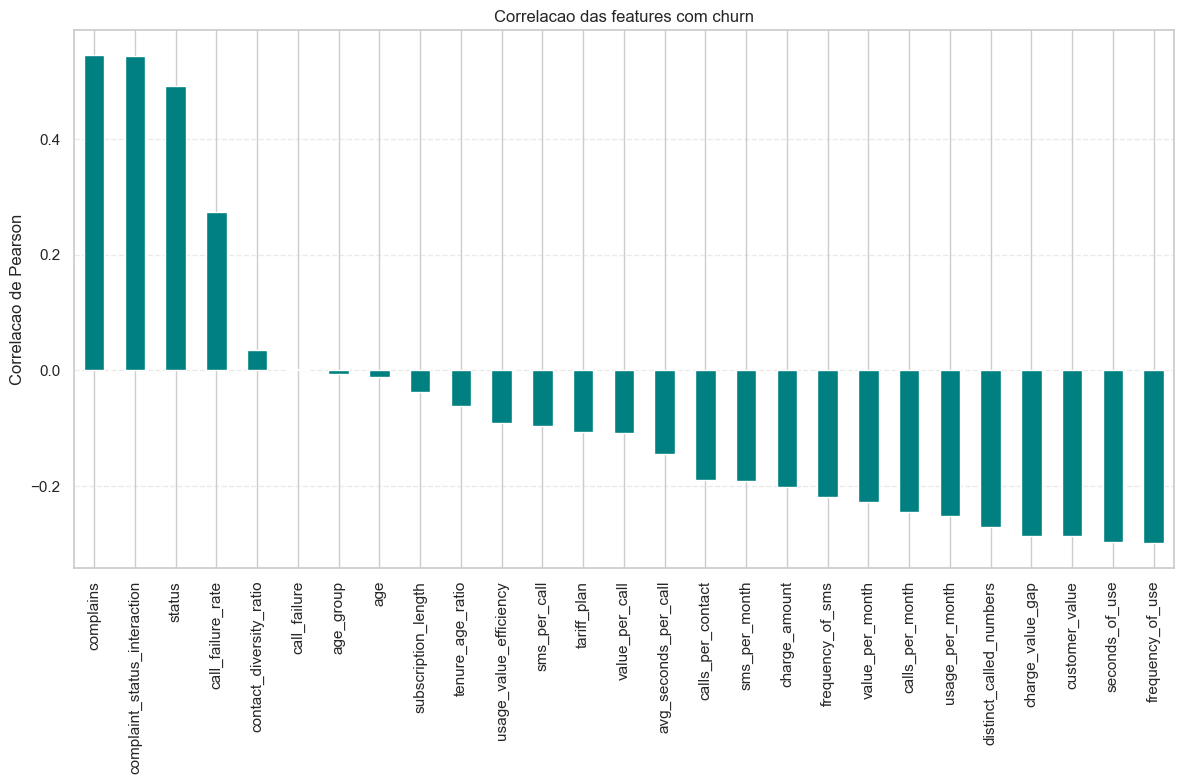

,correlation_with_churn
complains,0.5461
complaint_status_interaction,0.5431
status,0.4929
call_failure_rate,0.2748
contact_diversity_ratio,0.0346
call_failure,0.0033
age_group,-0.0059
age,-0.0115
subscription_length,-0.0380
tenure_age_ratio,-0.0606


In [54]:
# Correlacao das features com a target apos o feature engineering.
churn_correlation = (
    engineered_df.corr(numeric_only=True)["churn"]
    .drop("churn")
    .sort_values(ascending=False)
)

%matplotlib inline

plt.figure(figsize=(12, 8))
churn_correlation.plot(kind="bar", color="teal")
plt.title("Correlacao das features com churn")
plt.ylabel("Correlacao de Pearson")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

display(churn_correlation.to_frame("correlation_with_churn").round(4))


### Interpretacao do grafico de correlacao com churn

**O que este grafico mostra:** a forca e a direcao da correlacao linear entre cada feature e a variavel target `churn`.

**Por que ele e importante:** ele serve como uma primeira validacao das features novas. Se uma feature criada nao mostra qualquer relacao com o alvo e tambem nao aparece depois em importancia de modelo, ela pode estar adicionando mais ruido do que sinal.

**Como interpretar com cautela:** correlacao baixa nao significa automaticamente que a feature e inutil, porque modelos nao lineares capturam interacoes e padroes que a correlacao de Pearson nao enxerga. Ainda assim, essa analise ajuda a filtrar features evidentemente fracas e a reforcar features com sinal plausivel.

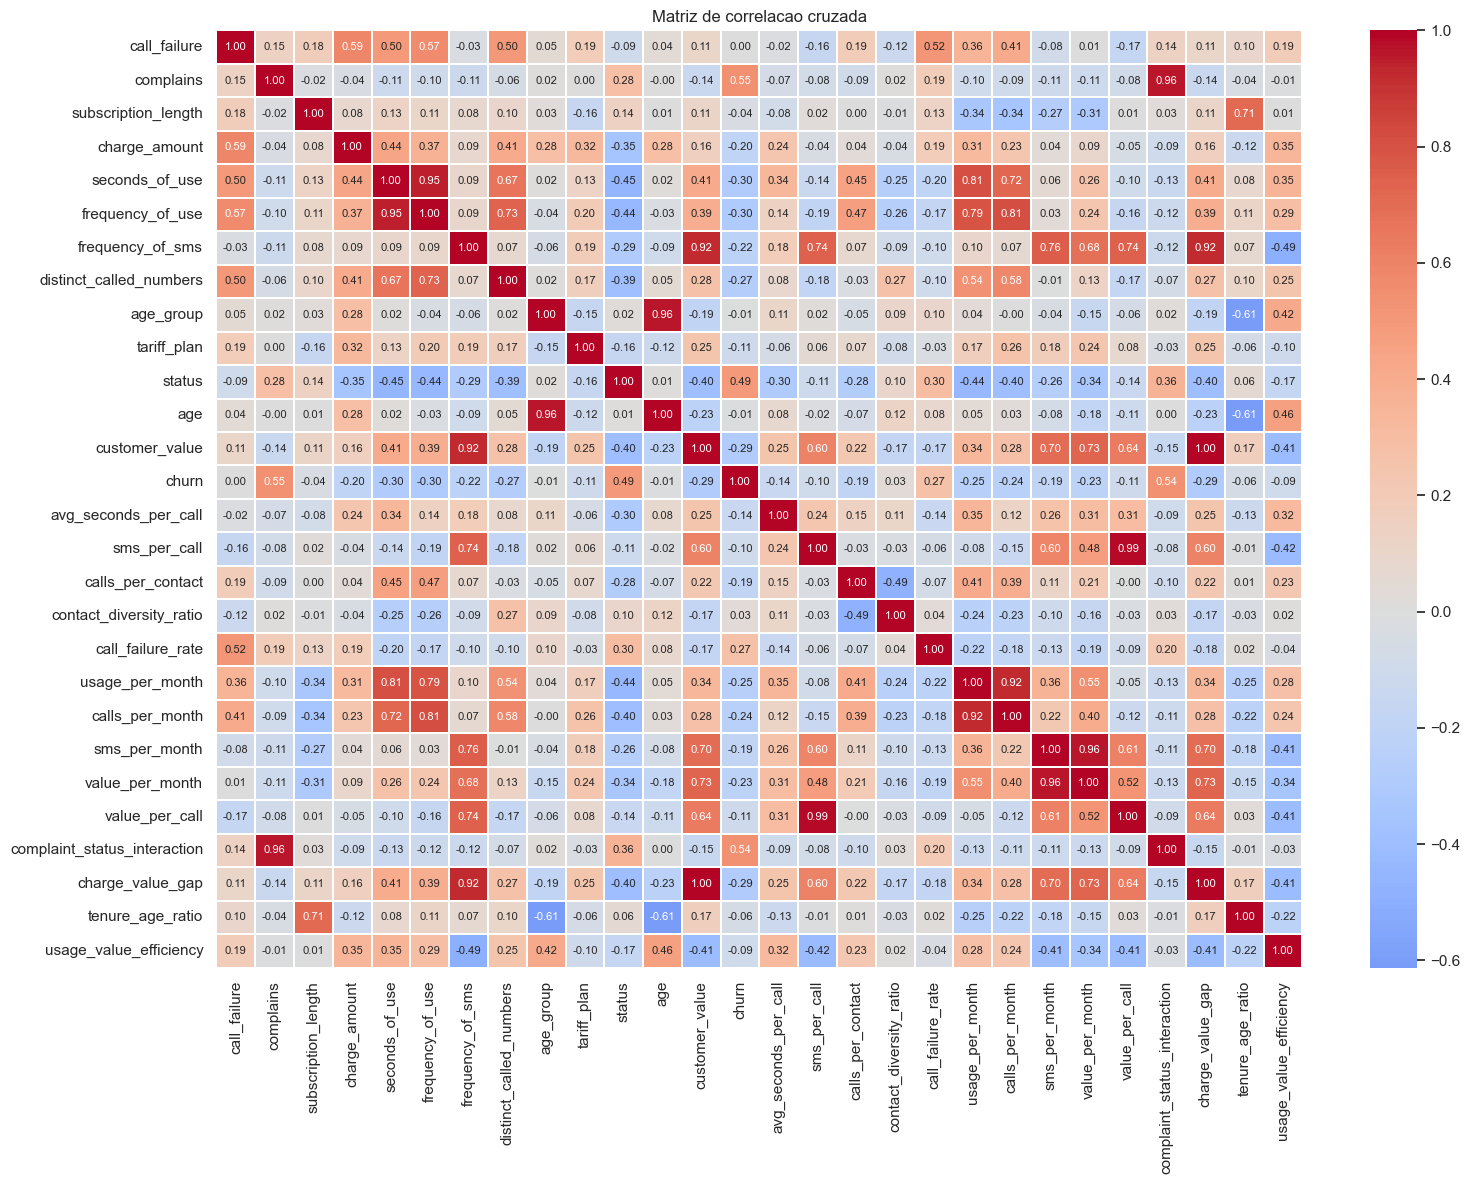

,feature_1,feature_2,correlation,abs_correlation
361,customer_value,charge_value_gap,1.0000,1.0000
443,sms_per_call,value_per_call,0.9858,0.9858
235,age_group,age,0.9609,0.9609
610,sms_per_month,value_per_month,0.9574,0.9574
52,complains,complaint_status_interaction,0.9572,0.9572
117,seconds_of_use,frequency_of_use,0.9451,0.9451
193,frequency_of_sms,charge_value_gap,0.9230,0.9230
180,frequency_of_sms,customer_value,0.9229,0.9229
552,usage_per_month,calls_per_month,0.9193,0.9193
160,frequency_of_use,calls_per_month,0.8135,0.8135


In [72]:
# Matriz de correlacao cruzada para inspecionar redundancia entre as features.
corr_matrix = engineered_df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8}
)
plt.title("Matriz de correlacao cruzada")
plt.tight_layout()
plt.show()

# Pares com correlacao absoluta mais alta ajudam a localizar multicolinearidade.
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper_triangle.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()
high_corr_pairs = high_corr_pairs.sort_values("abs_correlation", ascending=False)

display(high_corr_pairs.head(15).round(4))

### Interpretacao da matriz de correlacao cruzada

**O que este grafico mostra:** o relacionamento linear entre todas as features da base enriquecida, incluindo as variaveis derivadas.

**Por que ele e importante:** ele ajuda a identificar multicolinearidade e redundancia. Se duas features carregam praticamente o mesmo sinal, isso pode dificultar interpretacao, inflar instabilidade em modelos lineares e tornar a explicacao de negocio menos clara.

**Como usar esse resultado na pratica:**

- se uma feature nova estiver fortemente correlacionada com uma original, ela ainda pode ser util se for mais interpretavel ou se aparecer com mais importancia no modelo final;
- em modelos de arvore, correlacao alta costuma ser menos problematica para performance, mas continua relevante para explicabilidade;
- essa etapa nao substitui modelagem, mas ajuda a decidir quais variaveis merecem entrar, sair ou ao menos ser monitoradas com mais cuidado.

### Complemento metodologico: significancia estatistica na correlacao cruzada

A matriz de correlacao tradicional mostra a intensidade e o sinal da relacao linear entre as variaveis, mas nao informa se aquele valor pode ser tratado como um sinal estatisticamente consistente ou apenas como uma oscilacao amostral. Nesta versao complementar, usamos o teste de Pearson para destacar apenas pares com `p < 0.05`.

**O que significa ser significativo neste contexto:** significa que, sob a hipotese nula de ausencia de correlacao linear entre duas variaveis, o valor observado seria pouco provavel de ocorrer apenas por acaso.

**Como isso influencia a leitura do notebook:**

- ajuda a separar correlacoes que merecem mais atencao de padroes mais frageis;
- fortalece a discussao de multicolinearidade antes do treino;
- melhora a justificativa metodologica da secao de validacao das features;
- nao substitui a validacao por performance, importance ou holdout, porque uma feature pode ser util para modelos nao lineares mesmo sem alta correlacao linear.

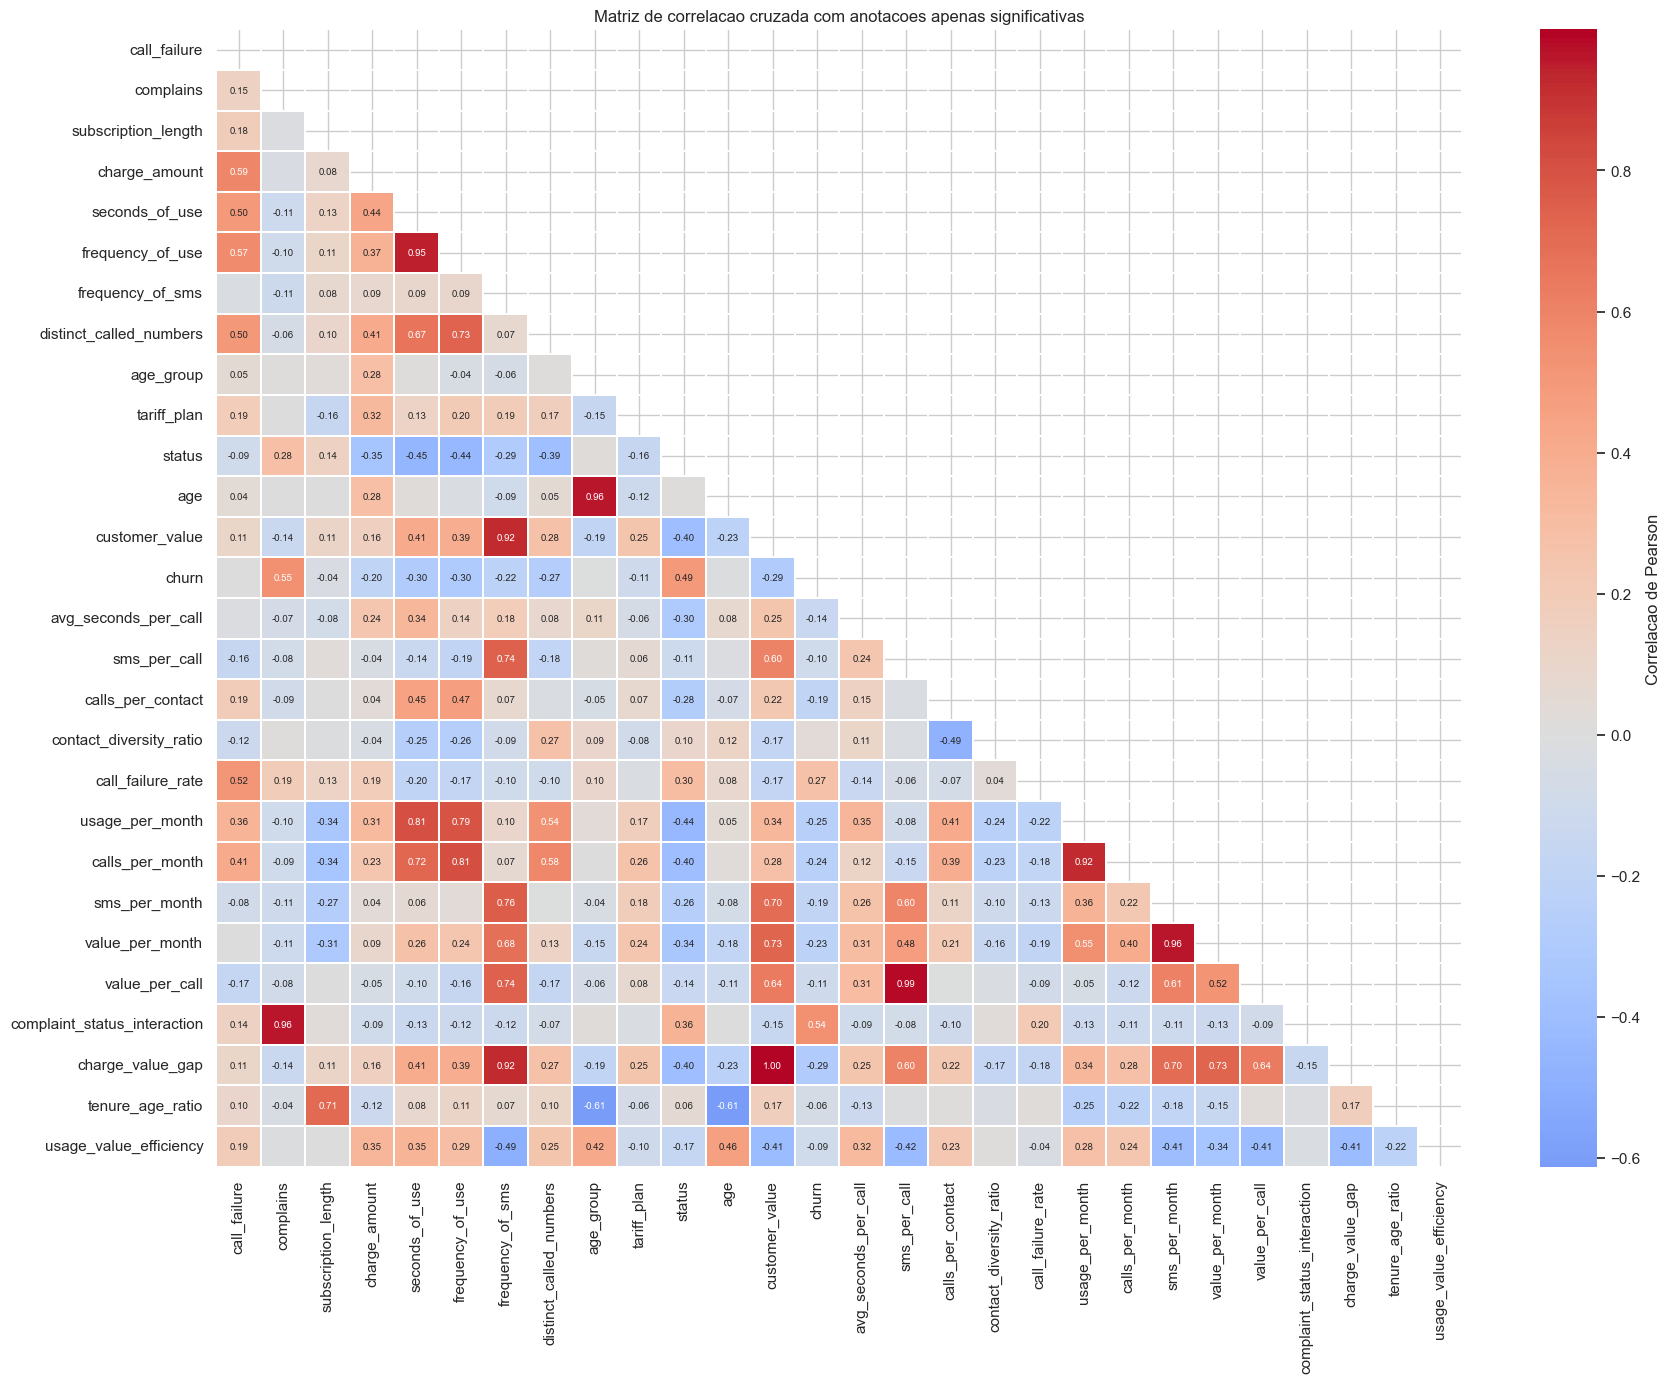

,feature_1,feature_2,p_value,correlation,abs_correlation
712,charge_value_gap,customer_value,0.0,1.0000,1.0000
659,value_per_call,sms_per_call,0.0,0.9858,0.9858
316,age,age_group,0.0,0.9609,0.9609
637,value_per_month,sms_per_month,0.0,0.9574,0.9574
673,complaint_status_interaction,complains,0.0,0.9572,0.9572
144,frequency_of_use,seconds_of_use,0.0,0.9451,0.9451
706,charge_value_gap,frequency_of_sms,0.0,0.9230,0.9230
342,customer_value,frequency_of_sms,0.0,0.9229,0.9229
579,calls_per_month,usage_per_month,0.0,0.9193,0.9193
565,calls_per_month,frequency_of_use,0.0,0.8135,0.8135


,feature_1,feature_2,p_value,correlation,abs_correlation
0,calls_per_month,age_group,0.9957,-0.0001,0.0001
1,age,complains,0.9830,-0.0004,0.0004
2,tariff_plan,complains,0.8955,0.0025,0.0025
3,calls_per_contact,subscription_length,0.8704,0.0031,0.0031
4,value_per_call,calls_per_contact,0.8668,-0.0031,0.0031
5,churn,call_failure,0.8598,0.0033,0.0033
6,complaint_status_interaction,age,0.8332,0.0039,0.0039
7,churn,age_group,0.7533,-0.0059,0.0059
8,age,subscription_length,0.7529,0.0059,0.0059
9,usage_value_efficiency,subscription_length,0.7272,0.0065,0.0065


In [76]:
# Heatmap complementar: anota apenas correlacoes estatisticamente significativas.
numeric_df = engineered_df.select_dtypes(include="number")
corr_matrix_significance = numeric_df.corr()

pval_matrix = pd.DataFrame(
    np.ones((numeric_df.shape[1], numeric_df.shape[1])),
    index=numeric_df.columns,
    columns=numeric_df.columns,
)

for i, col_i in enumerate(numeric_df.columns):
    for j, col_j in enumerate(numeric_df.columns):
        if i == j:
            pval_matrix.loc[col_i, col_j] = 0.0
        else:
            _, p_value = pearsonr(numeric_df[col_i], numeric_df[col_j])
            pval_matrix.loc[col_i, col_j] = p_value

annot_matrix = corr_matrix_significance.copy().astype(object)

for i in range(corr_matrix_significance.shape[0]):
    for j in range(corr_matrix_significance.shape[1]):
        if i == j:
            annot_matrix.iloc[i, j] = ""
        elif pval_matrix.iloc[i, j] < 0.05:
            annot_matrix.iloc[i, j] = f"{corr_matrix_significance.iloc[i, j]:.2f}"
        else:
            annot_matrix.iloc[i, j] = ""

mask = np.triu(np.ones_like(corr_matrix_significance, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix_significance,
    mask=mask,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    annot=annot_matrix,
    fmt="",
    annot_kws={"size": 7},
    cbar_kws={"label": "Correlacao de Pearson"},
)
plt.title("Matriz de correlacao cruzada com anotacoes apenas significativas")
plt.tight_layout()
plt.show()

# Pares com significancia estatistica na correlacao cruzada.
significant_pairs = (
    pval_matrix.where(~np.triu(np.ones(pval_matrix.shape), k=0).astype(bool))
    .stack()
    .rename("p_value")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
significant_pairs["correlation"] = significant_pairs.apply(
    lambda row: corr_matrix_significance.loc[row["feature_1"], row["feature_2"]],
    axis=1,
)
significant_pairs["abs_correlation"] = significant_pairs["correlation"].abs()
significant_pairs = significant_pairs[significant_pairs["p_value"] < 0.05].sort_values("abs_correlation", ascending=False)

display(significant_pairs.head(15).round(4))

# Pares sem significancia estatistica na correlacao cruzada.
non_significant_pairs = (
    pval_matrix.where(~np.triu(np.ones(pval_matrix.shape), k=0).astype(bool))
    .stack()
    .rename("p_value")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)

non_significant_pairs["correlation"] = non_significant_pairs.apply(
    lambda row: corr_matrix_significance.loc[row["feature_1"], row["feature_2"]],
    axis=1,
)
non_significant_pairs["abs_correlation"] = non_significant_pairs["correlation"].abs()

non_significant_pairs = (
    non_significant_pairs[non_significant_pairs["p_value"] >= 0.05]
    .sort_values(["p_value", "abs_correlation"], ascending=[False, False])
    .reset_index(drop=True)
)

display(non_significant_pairs.head(15).round(4))

### Interpretacao do heatmap com significancia

**O que este grafico mostra:** a mesma matriz de correlacao cruzada da base enriquecida, mas com anotacoes numericas apenas nos pares cuja correlacao foi estatisticamente significativa ao nivel de 5%.

**Por que ele e importante:** essa camada adicional reduz poluicao visual e reforca quais relacoes lineares tem suporte estatistico mais consistente. Isso melhora a narrativa da validacao das features, principalmente quando o objetivo e discutir redundancia, multicolinearidade e governanca do conjunto de variaveis.

**Como esse complemento deve ser usado:**

- correlacao significativa nao significa automaticamente que a feature deve entrar no modelo;
- correlacao nao significativa nao implica inutilidade preditiva, especialmente em modelos nao lineares;
- pares com alta correlacao e significancia merecem mais atencao na interpretacao, principalmente para modelos lineares ou para explicacao executiva do modelo;
- a decisao final continua dependendo do benchmark, do holdout e da importancia observada no modelo vencedor.

Em outras palavras, esta versao do notebook nao muda a logica de modelagem, mas torna a secao de validacao mais rigorosa e mais facil de defender tecnicamente.

## Execucao completa do pipeline

O bloco abaixo reproduz a logica central de `src/churn_modeling.py`:

- prepara o dataset enriquecido,
- monta os modelos,
- executa cross-validation,
- avalia holdout,
- calcula permutation importance,
- compara `raw vs engineered`,
- analisa threshold,
- salva artefatos tabulares e visuais.

In [56]:
# Separa preditores e target a partir da base enriquecida.
X = engineered_df.drop(columns=["churn"])
y = engineered_df["churn"].astype(int)
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
models = build_models(X.columns.tolist(), scale_pos_weight)

# Benchmark principal com cross-validation e avaliacao final em holdout.
cv_df = evaluate_with_cross_validation(X, y, models)
holdout_df, probabilities, X_train, y_train, X_test, y_test = evaluate_on_holdout(X, y, models)

# Reajusta o melhor modelo em treino para explicabilidade e thresholding.
best_model_name = str(cv_df.loc[0, "model"])
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
best_proba = probabilities[best_model_name]
best_pred = (best_proba >= 0.50).astype(int)

permutation = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=1,
)
feature_df = (
    pd.DataFrame({"feature": X.columns, "importance": permutation.importances_mean})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

comparison_df = compare_raw_vs_engineered(raw_df, engineered_df)
threshold_df, best_threshold = build_threshold_table(y_train, best_model.predict_proba(X_train)[:, 1])

# Resume os principais achados para consumo posterior por tabelas e artefatos.
summary = {
    "dataset_rows": int(engineered_df.shape[0]),
    "dataset_columns": int(engineered_df.shape[1]),
    "positive_rate": float(y.mean()),
    "best_model": best_model_name,
    "best_model_holdout_metrics": holdout_df.loc[holdout_df["model"] == best_model_name]
    .round(4)
    .to_dict(orient="records")[0],
    "best_threshold_on_train_f1": round(best_threshold, 4),
    "feature_engineering_gain_vs_raw_xgboost": {
        "roc_auc_delta": round(
            float(
                comparison_df.loc[comparison_df["feature_set"] == "engineered_features", "roc_auc"].iloc[0]
                - comparison_df.loc[comparison_df["feature_set"] == "raw_features", "roc_auc"].iloc[0]
            ),
            4,
        ),
        "average_precision_delta": round(
            float(
                comparison_df.loc[comparison_df["feature_set"] == "engineered_features", "average_precision"].iloc[0]
                - comparison_df.loc[comparison_df["feature_set"] == "raw_features", "average_precision"].iloc[0]
            ),
            4,
        ),
        "f1_delta": round(
            float(
                comparison_df.loc[comparison_df["feature_set"] == "engineered_features", "f1"].iloc[0]
                - comparison_df.loc[comparison_df["feature_set"] == "raw_features", "f1"].iloc[0]
            ),
            4,
        ),
    },
    "top_features": feature_df.head(10).round(4).to_dict(orient="records"),
    "feature_notes": FEATURE_NOTES,
}

# Persiste os artefatos para reuso em relatorios, portfolio e revisitas futuras.
save_artifacts(cv_df, holdout_df, feature_df, comparison_df, threshold_df, summary)

display(Markdown("### Resumo executivo gerado pelo pipeline"))
display(pd.DataFrame([summary["best_model_holdout_metrics"]]))
summary

### Resumo executivo gerado pelo pipeline

,model,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_average_precision
0,XGBoost,0.9667,0.9436,0.8804,0.9101,0.895,0.9875,0.9444


{'dataset_rows': 2850,
 'dataset_columns': 28,
 'positive_rate': 0.15649122807017543,
 'best_model': 'XGBoost',
 'best_model_holdout_metrics': {'model': 'XGBoost',
  'test_accuracy': 0.9667,
  'test_balanced_accuracy': 0.9436,
  'test_precision': 0.8804,
  'test_recall': 0.9101,
  'test_f1': 0.895,
  'test_roc_auc': 0.9875,
  'test_average_precision': 0.9444},
 'best_threshold_on_train_f1': 0.7691,
 'feature_engineering_gain_vs_raw_xgboost': {'roc_auc_delta': 0.0044,
  'average_precision_delta': 0.018,
  'f1_delta': 0.0434},
 'top_features': [{'feature': 'complains', 'importance': 0.0306},
  {'feature': 'call_failure_rate', 'importance': 0.0143},
  {'feature': 'status', 'importance': 0.013},
  {'feature': 'tenure_age_ratio', 'importance': 0.0112},
  {'feature': 'seconds_of_use', 'importance': 0.0109},
  {'feature': 'subscription_length', 'importance': 0.009},
  {'feature': 'frequency_of_use', 'importance': 0.0079},
  {'feature': 'avg_seconds_per_call', 'importance': 0.0064},
  {'featur

## Resultados tabulares

Essas tabelas consolidam a comparacao dos modelos sob duas perspectivas:

- `cross-validation`, para robustez estatistica da comparacao;
- `holdout`, para leitura final mais proxima do comportamento em dados nao vistos.

In [57]:
display(Markdown("### Benchmark em Cross-Validation"))
display(
    cv_df[
        [
            "model",
            "cv_roc_auc_mean",
            "cv_average_precision_mean",
            "cv_recall_mean",
            "cv_precision_mean",
            "cv_f1_mean",
            "cv_balanced_accuracy_mean",
        ]
    ].round(4)
)

display(Markdown("### Benchmark no Holdout"))
display(
    holdout_df[
        [
            "model",
            "test_roc_auc",
            "test_average_precision",
            "test_recall",
            "test_precision",
            "test_f1",
            "test_balanced_accuracy",
        ]
    ].round(4)
)

display(Markdown("### Impacto do Feature Engineering"))
display(comparison_df.round(4))


### Benchmark em Cross-Validation

,model,cv_roc_auc_mean,cv_average_precision_mean,cv_recall_mean,cv_precision_mean,cv_f1_mean,cv_balanced_accuracy_mean
0,XGBoost,0.9898,0.9593,0.9192,0.8911,0.9041,0.9490
1,LightGBM,0.9891,0.9604,0.8698,0.8998,0.8829,0.9256
2,Extra Trees,0.9879,0.9426,0.9170,0.8638,0.8892,0.9450
3,Random Forest,0.9856,0.9338,0.8565,0.8903,0.8721,0.9183
4,Gradient Boosting,0.9829,0.9351,0.7890,0.9204,0.8482,0.8881
5,Logistic Regression,0.9408,0.7929,0.8744,0.4996,0.6351,0.8552


### Benchmark no Holdout

,model,test_roc_auc,test_average_precision,test_recall,test_precision,test_f1,test_balanced_accuracy
0,LightGBM,0.9891,0.9505,0.8652,0.8953,0.8800,0.9232
1,Extra Trees,0.9876,0.9289,0.9101,0.8617,0.8852,0.9415
2,XGBoost,0.9875,0.9444,0.9101,0.8804,0.8950,0.9436
3,Random Forest,0.9851,0.9058,0.8315,0.9136,0.8706,0.9085
4,Gradient Boosting,0.9811,0.9202,0.7865,0.8974,0.8383,0.8849
5,Logistic Regression,0.9308,0.7783,0.8764,0.4937,0.6316,0.8550


### Impacto do Feature Engineering

,feature_set,roc_auc,average_precision,f1
0,raw_features,0.9854,0.9413,0.8607
1,engineered_features,0.9898,0.9593,0.9041


## Grafico 1: impacto do feature engineering

**O que o grafico mostra:** compara o desempenho medio do XGBoost com features originais versus features enriquecidas.

**Por que ele e importante:** ele valida se a engenharia de atributos gerou ganho real de sinal ou apenas aumentou a complexidade do pipeline.

**Insights gerados:**
- o ganho em `ROC AUC`, `Average Precision` e `F1` confirma que as features derivadas ajudaram;
- o aumento em `F1` e especialmente relevante, porque indica melhora pratica no equilibrio entre encontrar churners e evitar alarmes ruins;
- isso sustenta a decisao de manter o dataset enriquecido como base da modelagem.

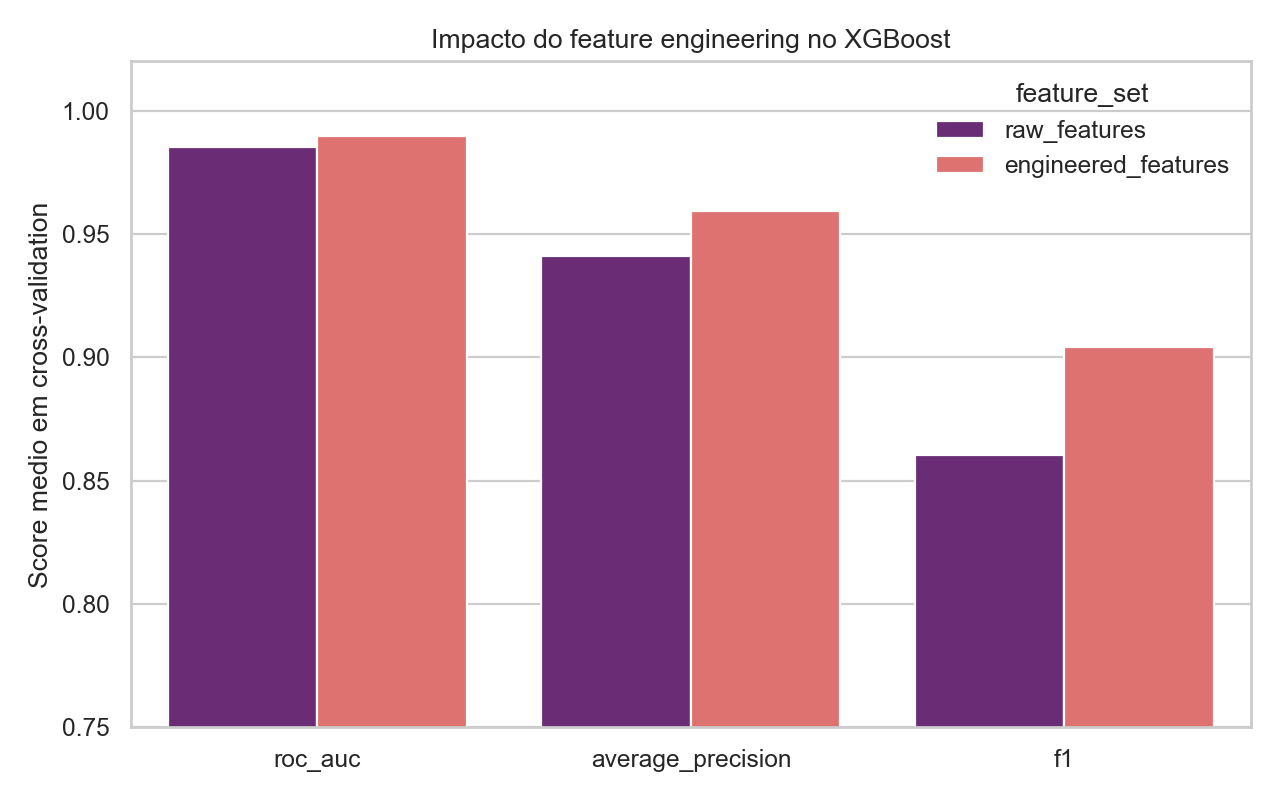

,feature_set,roc_auc,average_precision,f1
0,raw_features,0.9854,0.9413,0.8607
1,engineered_features,0.9898,0.9593,0.9041


In [58]:
plot_feature_set_comparison(comparison_df, ARTIFACTS_DIR / "feature_engineering_impact.png")
display(Image(filename=str(ARTIFACTS_DIR / "feature_engineering_impact.png")))
comparison_df.round(4)


## Grafico 2: comparacao de metricas entre modelos

**O que o grafico mostra:** coloca todos os modelos lado a lado no holdout usando as metricas mais relevantes para churn.

**Por que ele e importante:** modelos podem parecer equivalentes em uma metrica e bem diferentes em outra. O grafico mostra o trade-off entre discriminacao, precisao e sensibilidade.

**Insights gerados:**
- `XGBoost`, `LightGBM` e `Extra Trees` formam o grupo lider;
- `XGBoost` aparece como escolha final por combinar `F1`, `Recall`, `Precision` e `Balanced Accuracy` de forma muito equilibrada;
- `Logistic Regression` confirma o baseline, mas fica distante em `precision`, mostrando limite de um modelo linear neste problema.

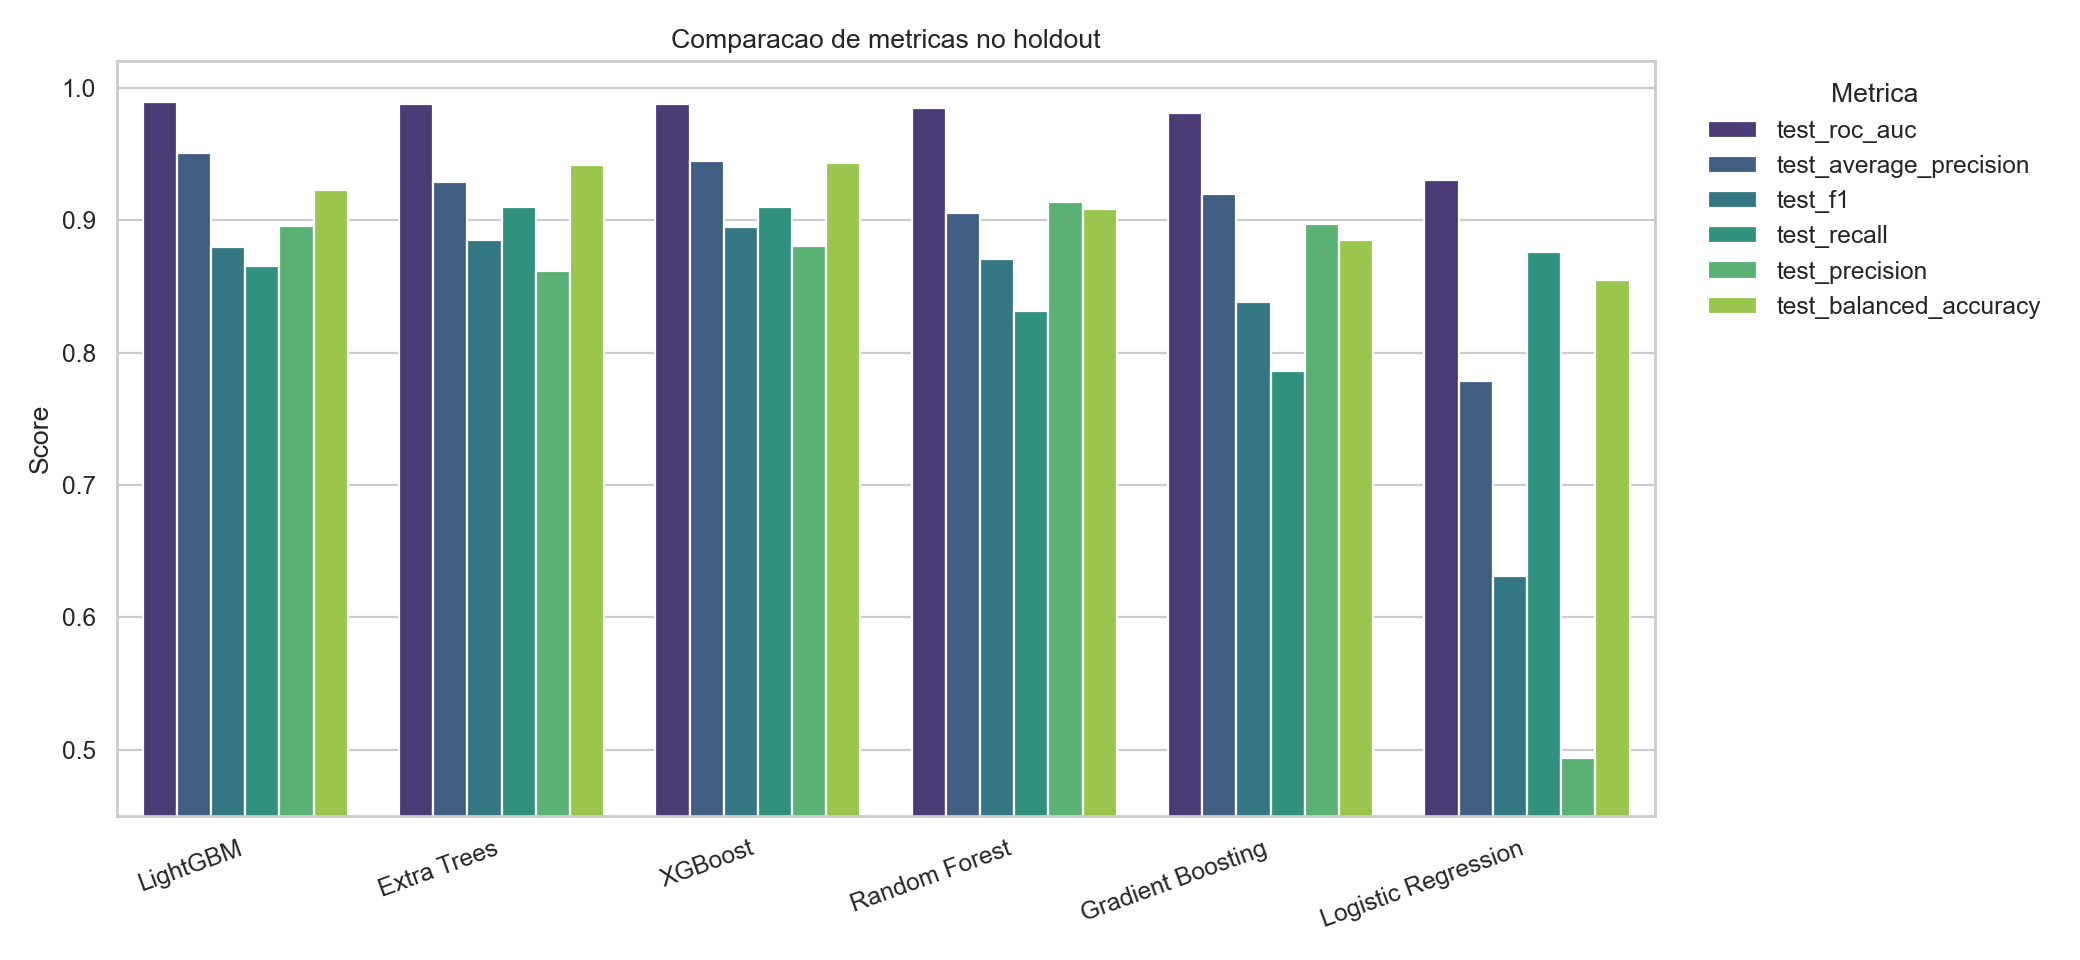

In [59]:
plot_model_comparison(holdout_df, ARTIFACTS_DIR / "model_metric_comparison.png")
display(Image(filename=str(ARTIFACTS_DIR / "model_metric_comparison.png")))


## Grafico 3: curvas ROC

**O que o grafico mostra:** compara a capacidade de cada modelo de separar churn e nao churn em diferentes thresholds.

**Por que ele e importante:** a ROC mede qualidade global de ranking e discriminacao, sendo um bom primeiro critico para comparar modelos.

**Insights gerados:**
- os modelos lideres ficam mais proximos do canto superior esquerdo, indicando separacao superior;
- a ROC muito alta mostra que o dataset possui sinal forte;
- como a classe de churn e minoritaria, esta leitura precisa ser complementada pela curva Precision-Recall.

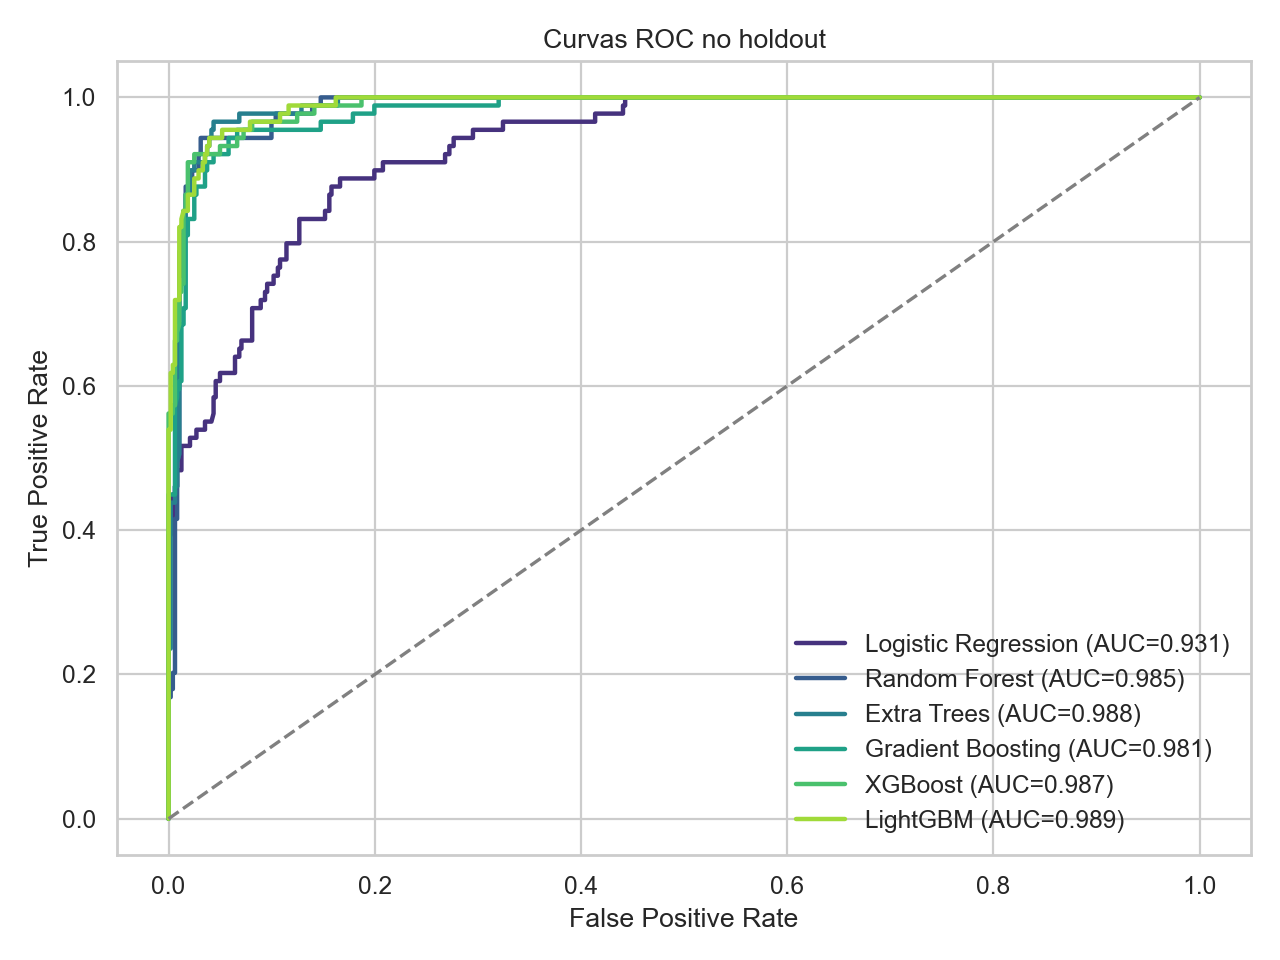

In [60]:
plot_roc_and_pr_curves(
    y_test,
    probabilities,
    ARTIFACTS_DIR / "roc_curves.png",
    ARTIFACTS_DIR / "precision_recall_curves.png",
)
display(Image(filename=str(ARTIFACTS_DIR / "roc_curves.png")))


## Grafico 4: curvas Precision-Recall

**O que o grafico mostra:** exibe como precision e recall se comportam quando o threshold se move ao longo do ranking de risco.

**Por que ele e importante:** para churn, em que a classe positiva e minoritaria, a Precision-Recall costuma refletir melhor a utilidade operacional do modelo.

**Insights gerados:**
- `XGBoost` e `LightGBM` sustentam melhor precision mesmo em niveis altos de recall;
- isso e particularmente relevante para campanhas de retencao, porque significa atingir muitos churners sem degradar tanto a qualidade da lista;
- o grafico reforca que os modelos lideres nao sao apenas bons em ranking geral, mas tambem em uso pratico.

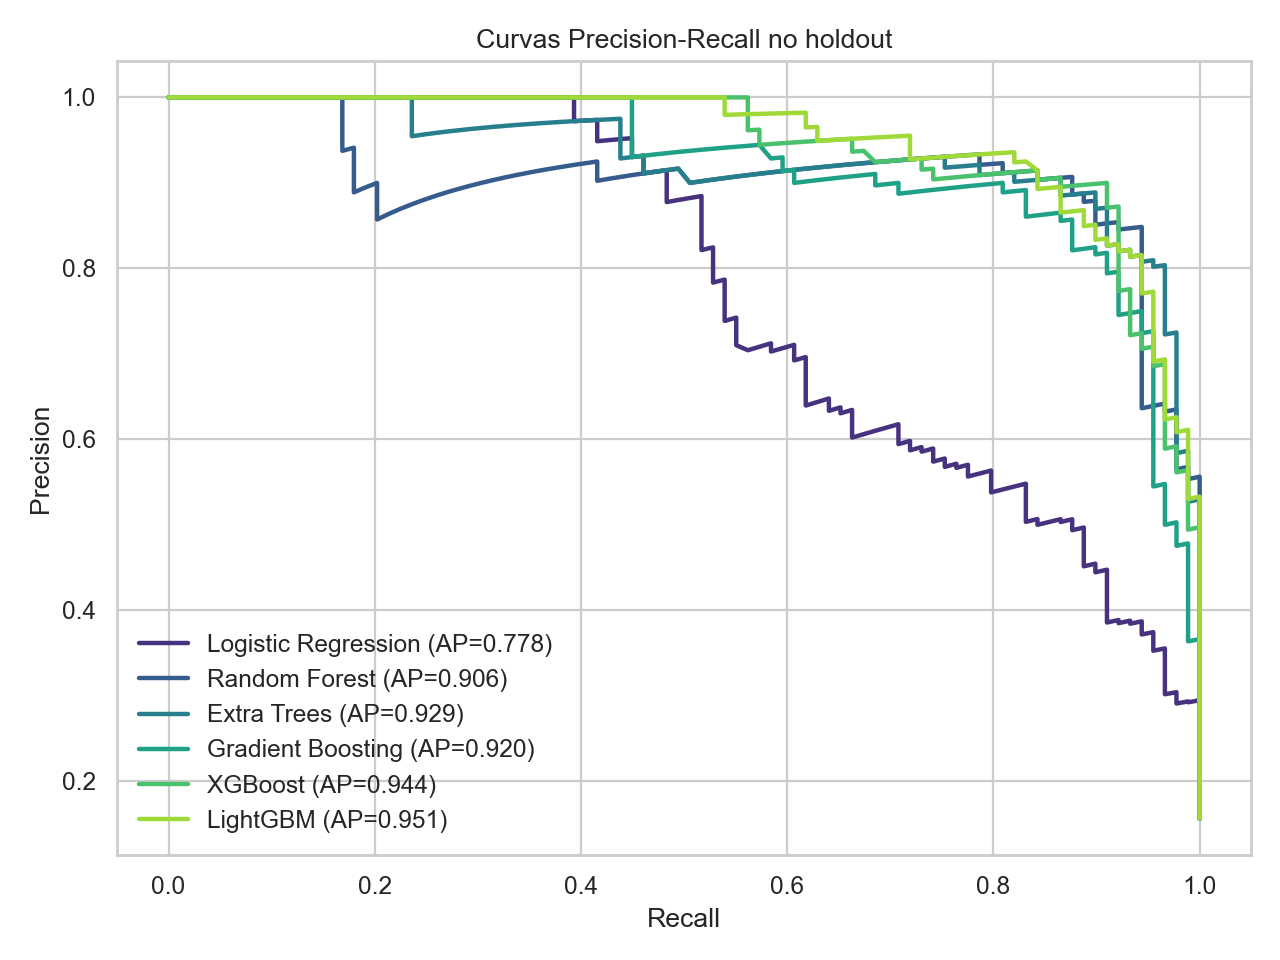

In [61]:
display(Image(filename=str(ARTIFACTS_DIR / "precision_recall_curves.png")))


## Grafico 5: matriz de confusao do melhor modelo

**O que o grafico mostra:** resume os acertos e erros do melhor modelo no holdout usando threshold `0.50`.

**Por que ele e importante:** traduz as metricas em contagem operacional de erros, o que facilita discutir custo de falsos positivos e falsos negativos.

**Insights gerados:**
- o modelo segura bem os verdadeiros negativos e ainda encontra grande parte dos churners;
- os falsos negativos ficam em nivel controlado, o que e desejavel quando perder um churner tem custo alto;
- o padrao de erro observado justifica manter `0.50` como threshold inicial.

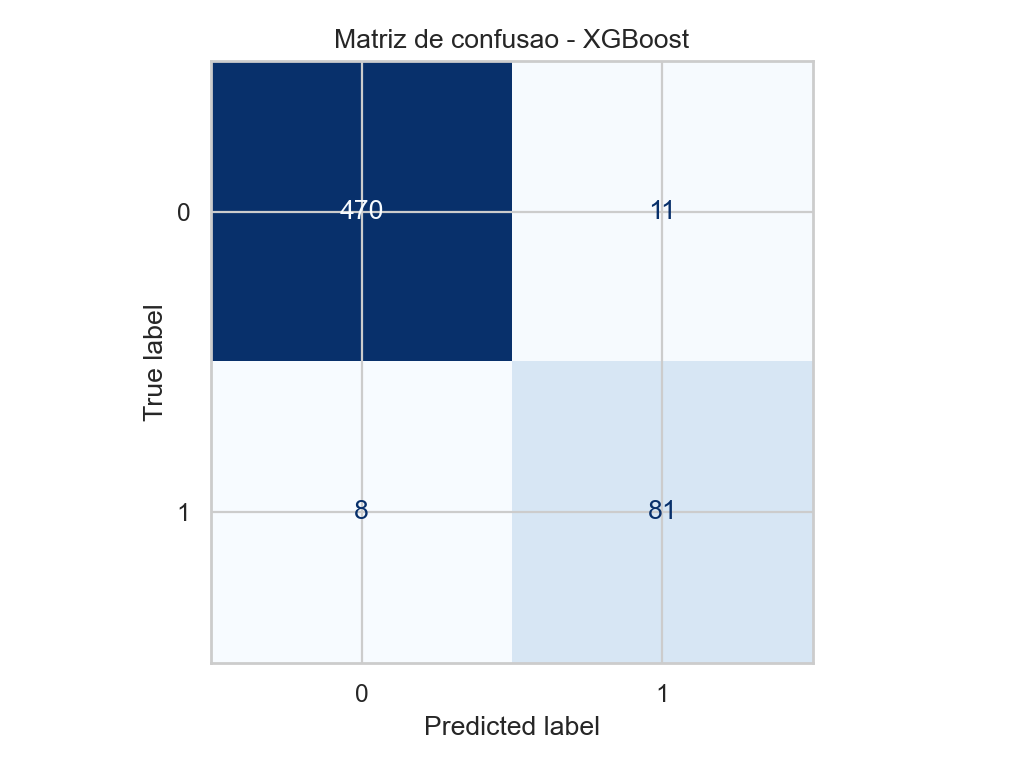

In [62]:
plot_confusion_matrix(y_test, best_pred, best_model_name, ARTIFACTS_DIR / "best_model_confusion_matrix.png")
display(Image(filename=str(ARTIFACTS_DIR / "best_model_confusion_matrix.png")))


## Grafico 6: importancia das features

**O que o grafico mostra:** ranking das features com maior impacto na performance do melhor modelo, medido por permutation importance.

**Por que ele e importante:** conecta performance preditiva a entendimento de negocio e ajuda a validar se o feature engineering foi realmente util.

**Insights gerados:**
- `complains` aparece como principal driver de churn, reforcando que experiencia ruim do cliente e central;
- `call_failure_rate` valida a hipotese de que friccao operacional tem papel direto na evasao;
- features como `tenure_age_ratio`, `avg_seconds_per_call` e `calls_per_month` mostram que sinais derivados agregam valor real ao modelo.

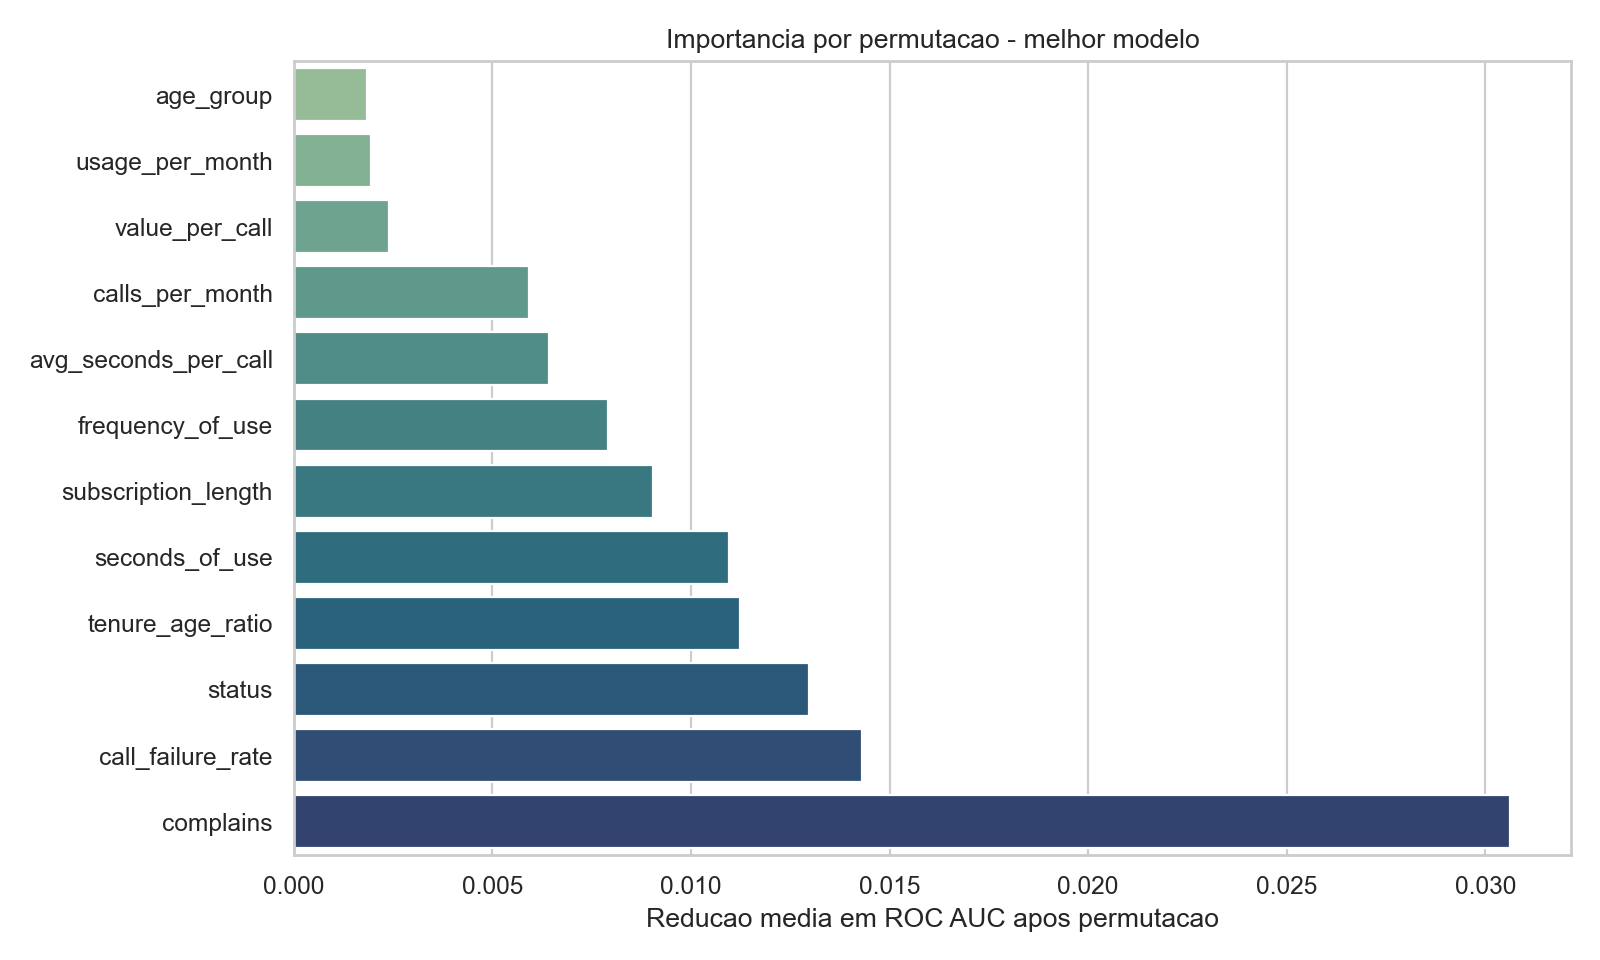

,feature,importance
0,complains,0.0306
1,call_failure_rate,0.0143
2,status,0.0130
3,tenure_age_ratio,0.0112
4,seconds_of_use,0.0109
5,subscription_length,0.0090
6,frequency_of_use,0.0079
7,avg_seconds_per_call,0.0064
8,calls_per_month,0.0059
9,value_per_call,0.0024


In [63]:
plot_feature_importance(feature_df, ARTIFACTS_DIR / "best_model_feature_importance.png")
display(Image(filename=str(ARTIFACTS_DIR / "best_model_feature_importance.png")))
feature_df.head(10).round(4)


## Grafico 7: trade-off de threshold

**O que o grafico mostra:** como `precision`, `recall` e `F1` variam quando mudamos o threshold do melhor modelo.

**Por que ele e importante:** a melhor escolha de threshold depende do objetivo operacional. Em churn, geralmente existe tensao entre capturar mais churners e manter uma lista de contato mais precisa.

**Insights gerados:**
- o melhor threshold puramente por `F1` no treino fica em torno de `0.7691`;
- apesar disso, o threshold `0.50` se mostrou mais equilibrado no holdout;
- a leitura correta aqui e que threshold e uma decisao de negocio, nao apenas matematica.

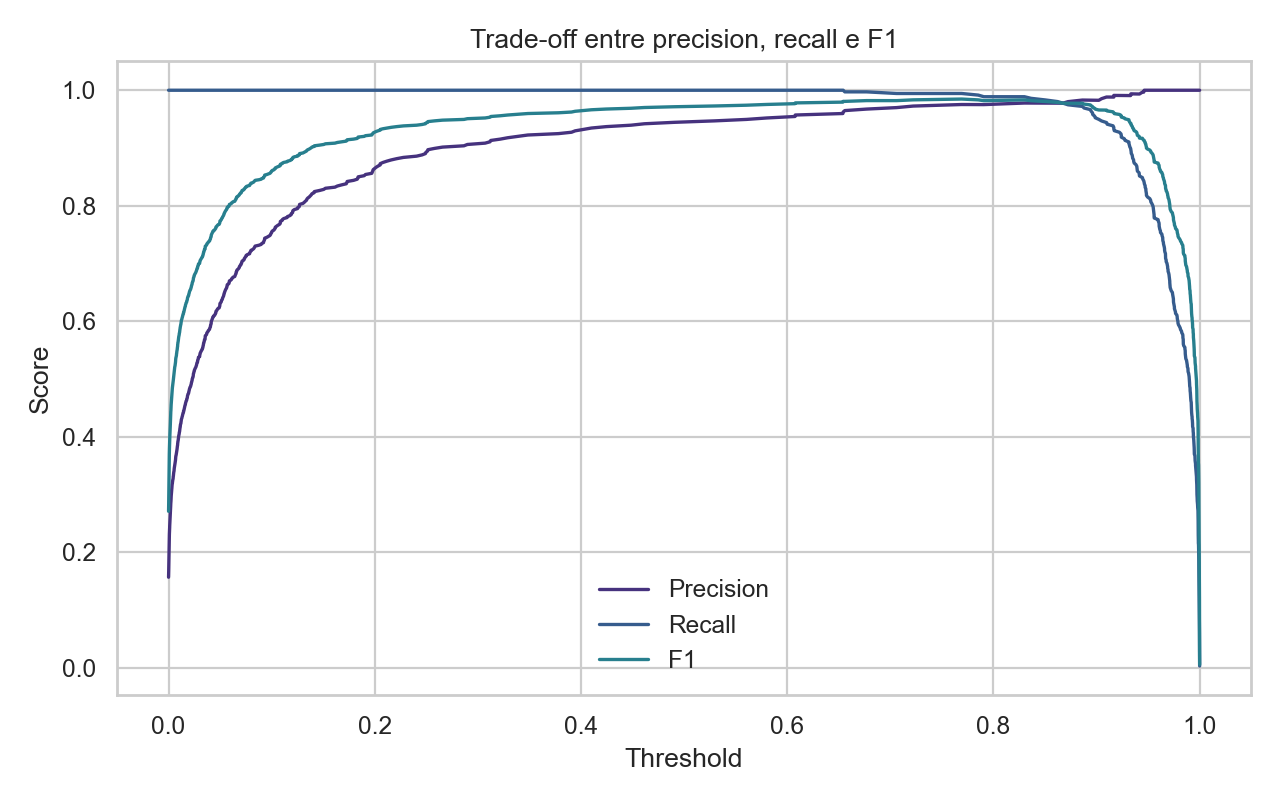

,threshold,precision,recall,f1
1888,0.7691,0.9753,0.9944,0.9847
1887,0.7221,0.9726,0.9944,0.9834
1889,0.7853,0.9752,0.9916,0.9833
1891,0.8300,0.9778,0.9888,0.9833
1885,0.6770,0.9674,0.9972,0.9821
1886,0.7060,0.9699,0.9944,0.9820
1890,0.7906,0.9751,0.9888,0.9819
1892,0.8364,0.9778,0.9860,0.9819
1883,0.6542,0.9623,1.0000,0.9808
1884,0.6558,0.9648,0.9972,0.9807


In [78]:
plot_threshold_tradeoff(threshold_df, ARTIFACTS_DIR / "threshold_tradeoff.png")
display(Image(filename=str(ARTIFACTS_DIR / "threshold_tradeoff.png")))
threshold_df.sort_values("f1", ascending=False).head(10).round(4)


## Persistencia do pipeline vencedor

A recomendacao aqui e salvar um `bundle` com o pipeline treinado e metadados essenciais. Isso facilita reuso posterior em batch scoring, API ou etapa de monitoramento.

Neste exemplo, o bundle contem:

- nome do modelo vencedor;
- pipeline completo treinado;
- colunas esperadas de entrada;
- nome da target;
- threshold operacional inicial;
- metricas finais do holdout;
- resumo do projeto gerado no notebook principal.

In [83]:
# Define a pasta oficial para os artefatos de modelo.
try:
    model_dir = ROOT_DIR / "artifacts" / "models"
except NameError:
    model_dir = Path.cwd().parent / "artifacts" / "models"

model_dir.mkdir(parents=True, exist_ok=True)

holdout_metrics = (
    holdout_df.loc[holdout_df["model"] == best_model_name]
    .iloc[0]
    .to_dict()
)

model_bundle = {
    "model_name": best_model_name,
    "pipeline": best_model,
    "feature_columns": list(X_train.columns),
    "target_column": "churn",
    "threshold": 0.50,
    "holdout_metrics": holdout_metrics,
    "project_summary": summary,
}

bundle_path = model_dir / "best_churn_pipeline.joblib"
metadata_path = model_dir / "best_churn_pipeline_metadata.json"

joblib.dump(model_bundle, bundle_path)

metadata = {
    "model_name": model_bundle["model_name"],
    "feature_columns": model_bundle["feature_columns"],
    "target_column": model_bundle["target_column"],
    "threshold": model_bundle["threshold"],
    "holdout_metrics": model_bundle["holdout_metrics"],
    "best_threshold_on_train_f1": summary.get("best_threshold_on_train_f1"),
    "top_features": summary.get("top_features", []),
}

with metadata_path.open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Pipeline salvo em: {bundle_path}")
print(f"Metadata salva em: {metadata_path}")

Pipeline salvo em: c:\Users\Guilherme Cavalheri\Desktop\github\telecom-churn-prediction\artifacts\models\best_churn_pipeline.joblib
Metadata salva em: c:\Users\Guilherme Cavalheri\Desktop\github\telecom-churn-prediction\artifacts\models\best_churn_pipeline_metadata.json


### Por que salvar o pipeline inteiro

O ponto mais importante aqui e que o objeto salvo nao contem apenas o estimador final. Ele contem o `Pipeline` completo, incluindo preprocessamento. Isso evita divergencia entre treino e inferencia, principalmente em cenarios com imputacao, scaling ou transformacoes de features.

Em outras palavras: na hora de prever novos dados, o mesmo fluxo aplicado no treino sera reaplicado automaticamente.

### Exemplo de carga para inferencia futura

Depois de salvo, o pipeline pode ser carregado em outro notebook, script batch ou API. A unica exigencia e que os novos dados respeitem o schema esperado de colunas.

In [85]:
# Carrega o bundle e demonstra como usar o pipeline salvo.
loaded_bundle = joblib.load(bundle_path)
loaded_pipeline = loaded_bundle["pipeline"]

# Exemplo com os proprios dados de teste ja existentes no notebook principal.
loaded_proba = loaded_pipeline.predict_proba(X_test)[:, 1]
loaded_pred = (loaded_proba >= loaded_bundle["threshold"]).astype(int)

pd.DataFrame(
    {
        "pred_proba": loaded_proba[:10],
        "pred_label": loaded_pred[:10],
        "target_real": y_test.iloc[:10].to_numpy(),
    }
).round(4)

,pred_proba,pred_label,target_real
0,0.9114,1,1
1,0.0005,0,0
2,0.0089,0,0
3,0.0003,0,0
4,0.0981,0,0
5,0.0025,0,0
6,0.1975,0,1
7,0.0007,0,0
8,0.9728,1,1
9,0.0536,0,0


## Conclusao

O notebook confirma o mesmo resultado do pipeline por uma trilha totalmente reproduzivel dentro do ambiente interativo:

- o feature engineering agregou ganho real de performance;
- `XGBoost` foi o melhor modelo geral;
- os principais sinais de churn combinam reclamacao, falha operacional, intensidade de uso e ciclo de vida;
- os artefatos foram recriados e salvos novamente em `artifacts/modeling`.

Proxima evolucao recomendada: calibracao de probabilidade, tuning fino entre `XGBoost` e `LightGBM` e definicao do threshold com base no custo da operacao de retencao.

## Resumo Executivo

### Narrativa executiva

A modelagem confirmou que o churn nesta base nao e aleatorio: ele responde de forma consistente a sinais de experiencia ruim, friccao operacional e queda de intensidade de uso. A estrategia de feature engineering melhorou o poder preditivo do pipeline, especialmente no equilibrio entre `precision` e `recall`, o que torna a solucao mais util para uma operacao de retencao.

Entre os modelos avaliados, o `XGBoost` foi a recomendacao final por apresentar o melhor equilibrio geral entre capacidade de discriminacao, estabilidade e utilidade operacional. Na pratica, isso significa uma melhor priorizacao de clientes em risco sem inflar excessivamente a lista de falsos positivos.

Do ponto de vista de negocio, a principal mensagem e clara: clientes com reclamacoes, maior taxa de falhas e sinais de enfraquecimento de uso devem ser tratados cedo. Isso sugere que a melhor aplicacao do modelo nao e apenas prever cancelamento, mas acionar atendimento, qualidade e ofertas de retencao antes que o churn aconteca.

In [65]:
executive_summary_df = pd.DataFrame(
    [
        {"Dimensao": "Objetivo", "Resumo": "Identificar churners com um modelo robusto e acionavel para retencao."},
        {"Dimensao": "Melhor modelo", "Resumo": summary["best_model"]},
        {"Dimensao": "ROC AUC holdout", "Resumo": f"{summary['best_model_holdout_metrics']['test_roc_auc']:.4f}"},
        {"Dimensao": "Average Precision holdout", "Resumo": f"{summary['best_model_holdout_metrics']['test_average_precision']:.4f}"},
        {"Dimensao": "Recall holdout", "Resumo": f"{summary['best_model_holdout_metrics']['test_recall']:.4f}"},
        {"Dimensao": "Precision holdout", "Resumo": f"{summary['best_model_holdout_metrics']['test_precision']:.4f}"},
        {"Dimensao": "F1 holdout", "Resumo": f"{summary['best_model_holdout_metrics']['test_f1']:.4f}"},
        {"Dimensao": "Ganho do feature engineering", "Resumo": f"+{summary['feature_engineering_gain_vs_raw_xgboost']['f1_delta']:.4f} em F1 no XGBoost"},
        {"Dimensao": "Threshold sugerido", "Resumo": "Manter 0.50 como default inicial e calibrar por custo de operacao"},
    ]
)

executive_summary_df.style.hide(axis="index").set_caption("Quadro executivo da modelagem").set_properties(
    **{"text-align": "left"}
).set_table_styles(
    [
        {"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold"), ("text-align", "left")]},
        {"selector": "th", "props": [("background-color", "#16324f"), ("color", "white"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("padding", "8px 12px")]},
    ]
)

Dimensao,Resumo
Objetivo,Identificar churners com um modelo robusto e acionavel para retencao.
Melhor modelo,XGBoost
ROC AUC holdout,0.9875
Average Precision holdout,0.9444
Recall holdout,0.9101
Precision holdout,0.8804
F1 holdout,0.8950
Ganho do feature engineering,+0.0434 em F1 no XGBoost
Threshold sugerido,Manter 0.50 como default inicial e calibrar por custo de operacao


In [66]:
scorecard_df = holdout_df[
    [
        "model",
        "test_roc_auc",
        "test_average_precision",
        "test_recall",
        "test_precision",
        "test_f1",
        "test_balanced_accuracy",
    ]
].rename(
    columns={
        "model": "Modelo",
        "test_roc_auc": "ROC AUC",
        "test_average_precision": "Avg Precision",
        "test_recall": "Recall",
        "test_precision": "Precision",
        "test_f1": "F1",
        "test_balanced_accuracy": "Balanced Accuracy",
    }
).round(4)

scorecard_df.style.hide(axis="index").background_gradient(
    cmap="YlGn",
    subset=["ROC AUC", "Avg Precision", "Recall", "Precision", "F1", "Balanced Accuracy"],
).set_caption("Scorecard executivo dos modelos no holdout").set_table_styles(
    [
        {"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold"), ("text-align", "left")]},
        {"selector": "th", "props": [("background-color", "#1f6f8b"), ("color", "white"), ("font-weight", "bold")]},
    ]
)


Modelo,ROC AUC,Avg Precision,Recall,Precision,F1,Balanced Accuracy
LightGBM,0.989100,0.950500,0.865200,0.895300,0.880000,0.923200
Extra Trees,0.987600,0.928900,0.910100,0.861700,0.885200,0.941500
XGBoost,0.987500,0.944400,0.910100,0.880400,0.895000,0.943600
Random Forest,0.985100,0.905800,0.831500,0.913600,0.870600,0.908500
Gradient Boosting,0.981100,0.920200,0.786500,0.897400,0.838300,0.884900
Logistic Regression,0.930800,0.778300,0.876400,0.493700,0.631600,0.855000


In [67]:
top_driver_df = feature_df.head(8).copy()
top_driver_df["importance"] = top_driver_df["importance"].round(4)
top_driver_df.columns = ["Driver", "Importancia"]

top_driver_df.style.hide(axis="index").bar(subset=["Importancia"], color="#4c956c").set_caption(
    "Principais drivers do churn no melhor modelo"
).set_table_styles(
    [
        {"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold"), ("text-align", "left")]},
        {"selector": "th", "props": [("background-color", "#2a9d8f"), ("color", "white"), ("font-weight", "bold")]},
    ]
)


Driver,Importancia
complains,0.030600
call_failure_rate,0.014300
status,0.013000
tenure_age_ratio,0.011200
seconds_of_use,0.010900
subscription_length,0.009000
frequency_of_use,0.007900
avg_seconds_per_call,0.006400


### Leitura final para negocio

- O modelo ja esta forte o suficiente para ser usado como score prioritario de retencao.
- O maior risco esta concentrado em clientes com pior experiencia e sinais de degradacao operacional.
- O feature engineering foi relevante e deve ser mantido como parte oficial do pipeline.
- O proximo passo mais valioso nao e trocar de algoritmo imediatamente, mas calibrar threshold, integrar o score ao processo de retencao e medir uplift operacional, ou seja, sem modelo, a empresa aborda clientes de forma aleatória já com modelo, ela prioriza clientes com maior risco;

## Proximas etapas recomendadas

A evolucao natural deste projeto pode seguir em duas frentes complementares: refinamento da modelagem atual e estruturacao do fluxo para um cenario mais proximo de ML end-to-end.

### 1. Evolucao da modelagem

Mesmo com o bom desempenho observado, ainda existem oportunidades tecnicas relevantes para aumentar robustez e utilidade operacional do modelo:

- **calibracao de probabilidade**: verificar se as probabilidades previstas refletem bem o risco real de churn, o que e importante para priorizacao de clientes e tomada de decisao;
- **tuning fino entre `XGBoost` e `LightGBM`**: como ambos apareceram entre os modelos mais fortes, uma etapa adicional de ajuste pode capturar ganhos marginais de performance;
- **definicao do threshold com base em custo de operacao**: em vez de usar apenas o melhor ponto estatistico, ajustar o threshold conforme o trade-off entre custo de contato, taxa de retencao e perda esperada.

### 2. Evolucao para um fluxo de ML end-to-end

A base analitica e preditiva do projeto ja esta bem estabelecida. O proximo passo natural e preparar o modelo para uso fora do notebook, com maior reprodutibilidade operacional:

- **persistir o pipeline vencedor como artefato reutilizavel**: salvar o modelo com preprocessamento e configuracoes para garantir consistencia entre treino e inferencia;
- **extrair essa persistencia para uma funcao dedicada em `src/`**: por exemplo, `save_best_model(...)`, reduzindo dependencia do notebook para operacoes criticas;
- **criar um modulo de inferencia, como `src/predict.py`**: permitindo carregar o modelo salvo e gerar previsoes em novos dados;
- **adicionar validacao de schema e qualidade de entrada**: garantindo que os dados usados em inferencia respeitem as colunas, tipos e formatos esperados;
- **disponibilizar o modelo por uma interface de servico, como `FastAPI`**: facilitando integracao com outros sistemas e automatizacao de scoring;
- **planejar monitoramento e retreinamento**: acompanhando drift de dados, estabilidade das previsoes e necessidade de atualizar o modelo ao longo do tempo.

Em sintese, o projeto ja entrega uma etapa de modelagem madura e bem documentada. As proximas evolucoes recomendadas buscam transformar esse resultado em um fluxo mais robusto, reutilizavel e preparado para cenarios reais de uso.
